# VLAB_06 — Karst System vs. SuperflexPy Lumped Models

Couples the physically-based vlab karst simulation (MODFLOW-CFP) with three
conceptual rainfall–runoff models built in SuperflexPy. The vlab system acts
as a "virtual reality" reference; each SuperflexPy model is calibrated to its
spring discharge using differential evolution.

| Step | Description |
|------|-------------|
| 1 | Run vlab at hourly resolution (10 days, all-default parameters) — network + discharge plots |
| 2 | Define three SuperflexPy model structures (M1, M2, M3) |
| 3 | Calibrate each model to the vlab reference discharge |
| 4 | Plot and compare calibration results |

**SuperflexPy model structures**

| # | Structure | Free parameters |
|---|-----------|------------------|
| M1 | UnsaturatedReservoir → LinearReservoir | 5 |
| M2 | UnsaturatedReservoir → PowerReservoir | 6 |
| M3 | UnsaturatedReservoir → LinearReservoir → PowerReservoir | 7 |

All three models take hourly precipitation and evapotranspiration as inputs
and are calibrated against the spring discharge of the vlab reference simulation.

In [1]:
# import sys
# sys.path.insert(0, "../..")

import vlab
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## Configuration

In [2]:
N_DAYS         = 10           # 10-day study window at hourly resolution
N_HOURS        = N_DAYS * 24  # 240 hourly stress periods
START          = 104          # starting index in the daily climate data
NSTP           = 1            # 1 internal time step per MODFLOW stress period
N_WARMUP_TILES = 5            # how many times to tile the forcing for warmup
                              # (matches vlab.Epikarst n_tiles default)

WORKING_DIR = Path.cwd() / "runs"
WORKING_DIR.mkdir(exist_ok=True)

## Data Preparation

Load the bundled daily climate series at hourly resolution. Each daily value is
uniformly disaggregated to 24 hourly values (each hour = 1/24 of the daily total).
The study window is 10 days starting at daily index `START`.

In [3]:
data_full = vlab.Data.default(temporal_resolution='hourly')

# Convert the daily start index to its hourly equivalent
start_h = START * 24

data = vlab.Data(
    data_full.prec.iloc[start_h : start_h + N_HOURS],
    data_full.evap.iloc[start_h : start_h + N_HOURS],
)

print(f"Study period : {data.prec.index[0]}  —  {data.prec.index[-1]}")
print(f"  Precipitation : mean = {data.prec.mean():.4f} mm/h, "
      f"total = {data.prec.sum():.1f} mm")
print(f"  Evaporation   : mean = {data.evap.mean():.4f} mm/h")

Study period : 2016-04-14 00:00:00  —  2016-04-23 23:00:00
  Precipitation : mean = 0.3463 mm/h, total = 83.1 mm
  Evaporation   : mean = 0.0597 mm/h


## Reference vlab Simulation

Build a System with all parameter groups fixed at their defaults and
`temporal_resolution='hourly'`. The System automatically sets
`Groundwater.perlen = 3600 s` (one stress period = one hour).

The network is generated once and reused for the MODFLOW run, following
the same pattern as in VLAB_05.

In [4]:
s = vlab.System(
    temporal_resolution='hourly',
    groundwater=vlab.Groundwater(nstp=NSTP),
    data=data,
    recharge_params=vlab.RechargeParams(stochastic=False),
    network_structure=vlab.NetworkStructure(stochastic=False),
    network_properties=vlab.NetworkProperties(
        stochastic=False,
        values={"k_exchange": 1e-3}),
    aquifer_params=vlab.AquiferParams(stochastic=False),
)

print("Generating reference network...")
network = s.generate_network(
    random_state=None, working_dir=WORKING_DIR, cleanup=True
)
print(f"  inlets : {len(network.idxs_inlet)}  |  spring : {network.idxs_spring}")

Generating reference network...

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
  inlets : 5  |  spring : [100, 17, 1]


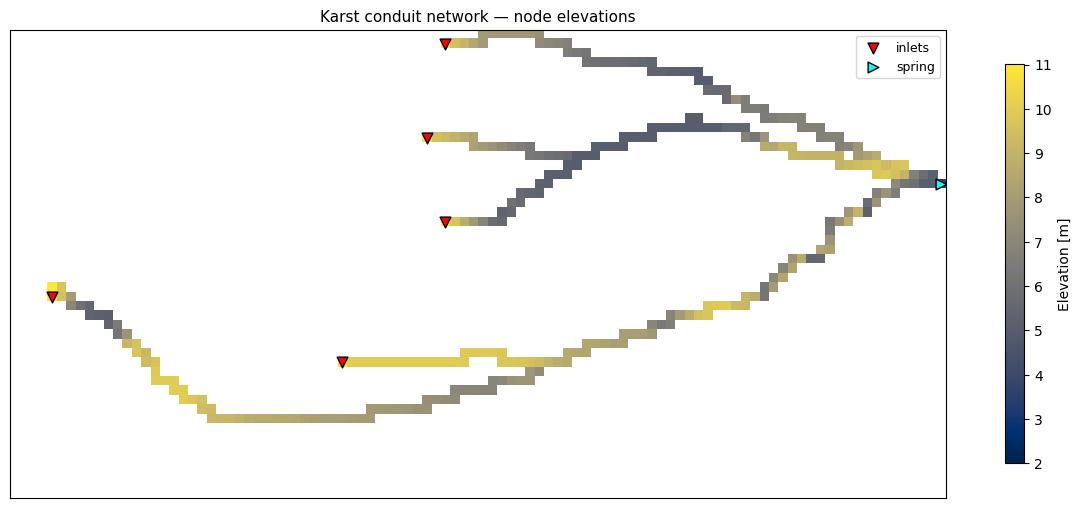

In [5]:
# Manually plot the conduit network: node elevations (colour) + inlet/spring markers.
# Cells with no conduit (elevation = 0) are shown as white (NaN).
fig, ax = plt.subplots(figsize=(12, 6))

nplot = network.validator.network.copy().astype(float)
nplot[nplot == 0] = np.nan

im = ax.matshow(nplot, cmap='cividis', vmin=2, vmax=11)
plt.colorbar(im, ax=ax, label='Elevation [m]', shrink=0.7)

inlets = np.array(network.idxs_inlet)   # shape (n_inlets, 3): [col, row, lay] 1-based
ax.scatter(inlets[:, 0] - 1, inlets[:, 1] - 1,
           c='r', marker='v', edgecolors='k', s=60, zorder=5, label='inlets')
ax.scatter([network.idxs_spring[0] - 1], [network.idxs_spring[1] - 1],
           c='cyan', marker='>', edgecolors='k', s=60, zorder=5, label='spring')

ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=9, loc='upper right')
plt.title('Karst conduit network — node elevations', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
print("Running reference simulation (hourly, 10 days = 240 stress periods)...")
success, Q_ref, heads = s.simulate_from_network(
    network, random_state=None, working_dir=WORKING_DIR, cleanup=True
)

if not success:
    raise RuntimeError("Reference simulation failed — check CFPv2.exe and model setup.")

# Index 0 of Q_ref is the steady-state warm-up; skip it and convert m³/s → L/s
Q_ref_Ls = Q_ref.values[1:] * 1000
t_hours  = np.arange(1, N_HOURS + 1)

print(f"  Q_peak = {Q_ref_Ls.max():.3f} L/s  |  Q_mean = {Q_ref_Ls.mean():.3f} L/s  "
      f"|  length = {len(Q_ref_Ls)} steps")

Running reference simulation (hourly, 10 days = 240 stress periods)...
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.25 s
  Q_peak = 259.136 L/s  |  Q_mean = 246.873 L/s  |  length = 240 steps


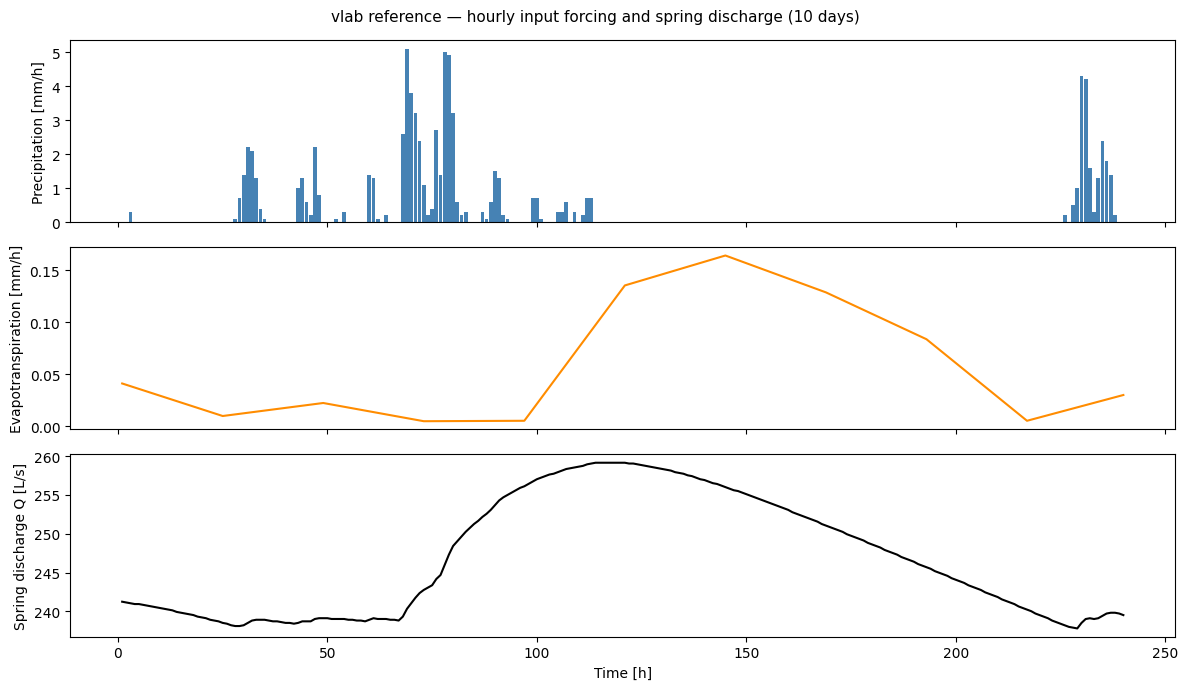

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

ax1.bar(t_hours, data.prec.values, color='steelblue', width=0.9)
ax1.set_ylabel('Precipitation [mm/h]')

ax2.plot(t_hours, data.evap.values, color='darkorange', lw=1.5)
ax2.set_ylabel('Evapotranspiration [mm/h]')

ax3.plot(t_hours, Q_ref_Ls, color='black', lw=1.5)
ax3.set_ylabel('Spring discharge Q [L/s]')
ax3.set_xlabel('Time [h]')

plt.suptitle(
    'vlab reference — hourly input forcing and spring discharge (10 days)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## SuperflexPy Lumped Models

Three HyMOD-inspired model structures are defined using SuperflexPy elements.
All three share the same upper zone element and differ only in how they route
effective precipitation to the spring.

> **Prerequisites** — if SuperflexPy is not yet installed, run
> `pip install superflexpy` in the active environment before executing the
> cells below.

The models run at hourly resolution (`dt = 1.0`). Inputs are precipitation
and potential evapotranspiration in mm/h; output is discharge in mm/h,
converted to L/s via the vlab catchment area.

**Element descriptions**

| Element | SuperflexPy class | Role | Key parameters |
|---------|-------------------|------|----------------|
| Upper zone | `UnsaturatedReservoir` (HBV) | Soil moisture store — partitions P into ET and effective precipitation | Smax, Ce, m, beta |
| Linear reservoir | `LinearReservoir` (HyMOD) | Linear slow-flow routing | k [1/h] |
| Non-linear reservoir | `PowerReservoir` (HBV) | Power-law fast-flow routing | k [1/h], alpha |

In [18]:
try:
    from superflexpy.implementation.elements.hymod import LinearReservoir
    from superflexpy.implementation.elements.hbv import (
        UnsaturatedReservoir,
        PowerReservoir,
    )
    from superflexpy.implementation.root_finders.pegasus import PegasusPython, PegasusNumba
    from superflexpy.implementation.numerical_approximators.implicit_euler import (
        ImplicitEulerPython, ImplicitEulerNumba
    )
    from superflexpy.implementation.elements.structure_elements import Transparent, Junction, Splitter
    from superflexpy.framework.unit import Unit
    from scipy.optimize import differential_evolution
    print("SuperflexPy imported successfully.")
except ImportError as e:
    print(f"Import error: {e}")
    print("Install SuperflexPy with:  pip install superflexpy")
    raise

SuperflexPy imported successfully.


In [9]:
# ── Numerical solver ──────────────────────────────────────────────────────────
# A single approximator instance is shared across all elements because it
# holds no internal state (it is purely a method object).
root_finder  = PegasusNumba(iter_max=100)
approximator = ImplicitEulerNumba(root_finder=root_finder)

# ── Unit conversion: mm/h → L/s ───────────────────────────────────────────────
# The vlab default grid is 50 rows × 100 cols × 25 m × 25 m = 3 125 000 m².
# Q [L/s] = Q [mm/h] × A [m²] × (0.001 m/mm) / (3600 s/h) × (1000 L/m³)
#         = Q [mm/h] × A [m²] / 3600
AREA_M2 = s.n_rows * s.n_cols * s.delr * s.delc   # m²

def mm_h_to_Ls(q_mm_h):
    return q_mm_h * AREA_M2 / 3600.0

print(f"Catchment area : {AREA_M2 / 1e6:.3f} km²")
print(f"Unit check     : 1 mm/h over catchment = {mm_h_to_Ls(1.0):.1f} L/s")

Catchment area : 3.125 km²
Unit check     : 1 mm/h over catchment = 868.1 L/s


## Model Definitions

Each `build_model_*` function constructs a SuperflexPy `Unit` configured with
`dt = 1.0` (one-hour time step). Unlike a naive setup that rebuilds the model
inside every objective-function evaluation, here each model is built **once**
(see the next cell) and then reused throughout calibration. During calibration
we only overwrite the free parameters and reset the internal stores — this is
far more efficient because the `Unit` structure and its numba solver bindings
are allocated a single time instead of thousands of times.

The `UnsaturatedReservoir` initial state `S0` is set to `Smax / 2` so that
each model starts with a partially filled soil store (neither empty nor
saturated). Because `Smax` changes during calibration, the objective function
re-applies `S0 = Smax / 2` after every `reset_states()` call (see below).

In [31]:
def build_model_1(Smax, Ce, m, beta, k_lr):
    # ── M1: UnsaturatedReservoir → LinearReservoir  (5 parameters) ───────────
    # The upper zone (uz) partitions hourly P and E_pot into actual ET and
    # effective precipitation. The linear reservoir (lr) routes effective
    # precipitation to the spring with a single recession coefficient.
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},   # start with half-filled soil store
        approximation=approximator,
        id='uz',
    )
    lr = LinearReservoir(
        parameters={'k': k_lr},
        states={'S0': 10.0},         # initial routing storage (mm)
        approximation=approximator,
        id='lr',
    )
    unit = Unit(layers=[[uz], [lr]], id='m1')
    unit.set_timestep(1.0)   # dt = 1 hour
    return unit


def build_model_2(Smax, Ce, m, beta, k_nr, alpha_nr):
    # ── M2: UnsaturatedReservoir → PowerReservoir  (6 parameters) ────────────
    # Same upper zone as M1. The power-law (non-linear) reservoir replaces the
    # linear routing, adding one extra free parameter (alpha).
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )
    nlr = PowerReservoir(
        parameters={'k': k_nr, 'alpha': alpha_nr},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr',
    )
    unit = Unit(layers=[[uz], [nlr]], id='m2')
    unit.set_timestep(1.0)
    return unit


def build_model_3(Smax, Ce, m, beta, k_lr, k_nr, alpha_nr):
    # ── M3: UnsaturatedReservoir → LinearReservoir → PowerReservoir  (7 params)
    # Cascade routing: effective precipitation first passes through the linear
    # slow-flow store, then through the non-linear fast-flow store. This gives
    # the model two routing time scales.
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )
    lr = LinearReservoir(
        parameters={'k': k_lr},
        states={'S0': 10.0},
        approximation=approximator,
        id='lr',
    )
    nlr = PowerReservoir(
        parameters={'k': k_nr, 'alpha': alpha_nr},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr',
    )
    unit = Unit(layers=[[uz], [lr], [nlr]], id='m3')
    unit.set_timestep(1.0)
    return unit

def build_model_4(Smax, Ce, m, beta, k_nr1, alpha_nr1, k_nr2, alpha_nr2, k_nr3, alpha_nr3):
    # ── M3: UnsaturatedReservoir → LinearReservoir → PowerReservoir  (7 params)
    # Cascade routing: effective precipitation first passes through the linear
    # slow-flow store, then through the non-linear fast-flow store. This gives
    # the model two routing time scales.
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )

    nlr1 = PowerReservoir(
        parameters={'k': k_nr1, 'alpha': alpha_nr1},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr1',
    )

    nlr2 = PowerReservoir(
        parameters={'k': k_nr2, 'alpha': alpha_nr2},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr2',
    )

    nlr3 = PowerReservoir(
        parameters={'k': k_nr3, 'alpha': alpha_nr3},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr3',
    )

    t = Transparent(id='transparent')
    s = Splitter(
        weight=[[0.5], [0.5]],
        direction=[[0], [0]],
        id='splitter'
    )
    j = Junction(
        direction=[[0, 0]],
        id='junction'
    )

    unit = Unit(layers=[[uz], [s], [nlr1, nlr2], [nlr3, t], [j]], id='m4')
    unit.set_timestep(1.0)
    return unit

In [32]:
# ── Build each model ONCE and prepare the (shared) forcing input ──────────────
# The models are constructed here with placeholder parameter values (the
# midpoint of each parameter's calibration bounds). These values are
# overwritten in every objective-function evaluation, so only the *structure*
# of each model matters at this point — not the specific numbers.

model_1 = build_model_1(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_lr=0.25)
model_2 = build_model_2(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_nr=0.25, alpha_nr=2.75)
model_3 = build_model_3(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_lr=0.25, k_nr=0.25, alpha_nr=2.75)
model_4 = build_model_4(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_nr1=0.25, alpha_nr1=2.75,
                        k_nr2=0.25, alpha_nr2=2.75,
                        k_nr3=0.25, alpha_nr3=2.75)

# Hourly forcing for the study period (mm/h).
prec_arr = data.prec.values
evap_arr = data.evap.values

# Tile the forcing N_WARMUP_TILES times so the model states can equilibrate
# before the actual study period. Only the last tile is scored in the
# objective function — identical to the warmup logic in vlab.Epikarst.
# The tiled input is the same for every calibration iteration, so we set it
# on each model just once, here, instead of re-setting it on every call.
prec_tiled = np.tile(prec_arr, N_WARMUP_TILES)
evap_tiled = np.tile(evap_arr, N_WARMUP_TILES)

for model in (model_1, model_2, model_3, model_4):
    model.set_input([prec_tiled, evap_tiled])

# Full hierarchical parameter names, in the SAME ORDER as the BOUNDS_* lists
# defined below. SuperflexPy names each parameter '<unit_id>_<element_id>_<param>'.
# These lists map the flat parameter vector handed to us by differential_evolution
# onto the named parameters of each pre-built model.
PARAM_NAMES_M1 = ['m1_uz_Smax', 'm1_uz_Ce', 'm1_uz_m', 'm1_uz_beta',
                  'm1_lr_k']
PARAM_NAMES_M2 = ['m2_uz_Smax', 'm2_uz_Ce', 'm2_uz_m', 'm2_uz_beta',
                  'm2_nlr_k', 'm2_nlr_alpha']
PARAM_NAMES_M3 = ['m3_uz_Smax', 'm3_uz_Ce', 'm3_uz_m', 'm3_uz_beta',
                  'm3_lr_k', 'm3_nlr_k', 'm3_nlr_alpha']
PARAM_NAMES_M4 = ['m4_uz_Smax', 'm4_uz_Ce', 'm4_uz_m', 'm4_uz_beta',
                  'm4_nlr1_k', 'm4_nlr1_alpha',
                  'm4_nlr2_k', 'm4_nlr2_alpha',
                  'm4_nlr3_k', 'm4_nlr3_alpha']

print("Models built once and forcing set:")
print(f"  M1 parameters: {model_1.get_parameters_name()}")
print(f"  M2 parameters: {model_2.get_parameters_name()}")
print(f"  M3 parameters: {model_3.get_parameters_name()}")
print(f"  M4 parameters: {model_4.get_parameters_name()}")

Models built once and forcing set:
  M1 parameters: ['m1_uz_Smax', 'm1_uz_Ce', 'm1_uz_m', 'm1_uz_beta', 'm1_lr_k']
  M2 parameters: ['m2_uz_Smax', 'm2_uz_Ce', 'm2_uz_m', 'm2_uz_beta', 'm2_nlr_k', 'm2_nlr_alpha']
  M3 parameters: ['m3_uz_Smax', 'm3_uz_Ce', 'm3_uz_m', 'm3_uz_beta', 'm3_lr_k', 'm3_nlr_k', 'm3_nlr_alpha']
  M4 parameters: ['m4_uz_Smax', 'm4_uz_Ce', 'm4_uz_m', 'm4_uz_beta', 'm4_nlr1_k', 'm4_nlr1_alpha', 'm4_nlr2_k', 'm4_nlr2_alpha', 'm4_nlr3_k', 'm4_nlr3_alpha']


## Calibration

Each model is calibrated by minimising `1 − NSE` (Nash–Sutcliffe Efficiency)
against the vlab reference discharge using
`scipy.optimize.differential_evolution`.

The objective function builds a fresh model for every candidate parameter set,
runs it over the 240-hour study period, converts the output to L/s, and returns
`1 − NSE`. Minimising this is equivalent to maximising NSE.

**Parameter bounds**

| Parameter | Bounds | Notes |
|-----------|--------|-------|
| Smax | (10, 500) mm | Maximum soil storage |
| Ce | (0.1, 2.0) | ET efficiency coefficient |
| m | (0.001, 0.1) | Smoothing factor (numerical; not a physical parameter) |
| beta | (0.5, 10.0) | Non-linearity of runoff generation |
| k_lr | (0.001, 0.5) 1/h | Linear reservoir recession rate |
| k_nr | (0.001, 0.5) 1/h | Power reservoir coefficient |
| alpha_nr | (0.5, 5.0) | Power reservoir exponent |

In [33]:
def nse(Q_obs, Q_sim):
    # Nash-Sutcliffe Efficiency: 1.0 = perfect fit, 0 = mean benchmark.
    denom = np.sum((Q_obs - np.mean(Q_obs)) ** 2)
    if denom < 1e-12:
        return -np.inf   # observations have no variance — degenerate case
    return 1.0 - np.sum((Q_obs - Q_sim) ** 2) / denom


def make_objective(model, param_names, Q_obs, n):
    # Build the objective function for a PRE-BUILT SuperflexPy model.
    #
    # model       : a Unit created once in the cell above (with its tiled
    #               forcing already set via set_input).
    # param_names : full hierarchical parameter names (PARAM_NAMES_M*), in the
    #               same order as the parameter vector handed over by
    #               differential_evolution.
    # Q_obs       : observed (vlab reference) discharge in L/s, one value per
    #               study-period hour.
    # n           : number of study-period hours (= len(prec_arr)); used to
    #               discard the warmup tiles from the model output.
    #
    # Only the free parameters and the internal stores are updated on each call
    # — the model structure and its input are never rebuilt.
    def objective(params):
        # 1. Overwrite the free parameters on the pre-built model.
        param_values = {}
        for name, value in zip(param_names, params):
            param_values[name] = value
        model.set_parameters(param_values)

        # 2. Reset all internal stores to their build-time initial values
        #    (routing reservoirs back to S0 = 10 mm, soil store back to the
        #    placeholder value used at build time).
        model.reset_states()

        # 3. Re-initialise the soil store at half of the CURRENT Smax. This is
        #    needed because reset_states() only restores the build-time S0, but
        #    Smax changes from one candidate parameter set to the next. The first
        #    entry of param_names is always the '<unit>_uz_Smax' parameter, so
        #    the matching soil-state name is obtained by swapping the suffix.
        smax = param_values[param_names[0]]
        soil_state_name = param_names[0].replace('_Smax', '_S0')
        model.set_states({soil_state_name: smax / 2.0})

        # 4. Run the model and discard the warmup tiles, keeping the last n steps.
        Q_sim_mm_h_full = model.get_output()[0]
        Q_sim_mm_h = Q_sim_mm_h_full[n * (N_WARMUP_TILES - 1):]

        # Small numerical negatives can appear at the start of a run; clip to zero.
        Q_sim_Ls = mm_h_to_Ls(np.maximum(Q_sim_mm_h, 0.0))
        return 1.0 - nse(Q_obs, Q_sim_Ls)
    return objective

# ── Parameter bounds ──────────────────────────────────────────────────────────
BOUNDS_UZ = [
    (10.0,  500.0),   # Smax  [mm]
    ( 0.1,    2.0),   # Ce    [-]
    (0.001,   0.1),   # m     [-]
    ( 0.5,   10.0),   # beta  [-]
]
BOUNDS_LR  = [(0.001, 0.5)]            # k_lr  [1/h]
BOUNDS_NLR = [(0.001, 0.5),            # k_nr  [1/h]
              (  0.5, 5.0)]            # alpha [-]

BOUNDS_M1 = BOUNDS_UZ + BOUNDS_LR
BOUNDS_M2 = BOUNDS_UZ + BOUNDS_NLR
BOUNDS_M3 = BOUNDS_UZ + BOUNDS_LR + BOUNDS_NLR
BOUNDS_M4 = BOUNDS_UZ + BOUNDS_NLR + BOUNDS_NLR + BOUNDS_NLR

print(f"M1: {len(BOUNDS_M1)} parameters")
print(f"M2: {len(BOUNDS_M2)} parameters")
print(f"M3: {len(BOUNDS_M3)} parameters")
print(f"M4: {len(BOUNDS_M4)} parameters")

M1: 5 parameters
M2: 6 parameters
M3: 7 parameters
M4: 10 parameters


In [34]:
# prec_arr / evap_arr and the pre-built models (model_1/2/3) come from the
# "Build each model ONCE" cell above.
n_hours = len(prec_arr)   # study-period length, used to strip the warmup tiles

DE_KWARGS = dict(
    seed=42,
    maxiter=500,
    tol=1e-1,
    atol=1e-1,
    disp=True,   # set True to watch generation-by-generation convergence
    popsize=15,   # population size multiplier (15 × n_params individuals)
    workers=1,    # single-threaded: the objective mutates one shared model
                  # object, so parallel workers (workers>1) would be unsafe.
)

# ── Model 1: UnsaturatedReservoir → LinearReservoir ──────────────────────────
print("Calibrating Model 1 (UZ → LR)...")
res1 = differential_evolution(
    make_objective(model_1, PARAM_NAMES_M1, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M1,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res1.fun:.4f}  |  converged: {res1.success}")

# ── Model 2: UnsaturatedReservoir → PowerReservoir ───────────────────────────
print("Calibrating Model 2 (UZ → NLR)...")
res2 = differential_evolution(
    make_objective(model_2, PARAM_NAMES_M2, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M2,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res2.fun:.4f}  |  converged: {res2.success}")

# ── Model 3: UnsaturatedReservoir → LinearReservoir → PowerReservoir ─────────
print("Calibrating Model 3 (UZ → LR → NLR)...")
res3 = differential_evolution(
    make_objective(model_3, PARAM_NAMES_M3, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M3,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res3.fun:.4f}  |  converged: {res3.success}")

# ── Model 4: UnsaturatedReservoir → Splitter → [PowRes, PowRes] → [PowRes, -] → [Junction] ─────────
print("Calibrating Model 4 (UZ → [NLR, NLR] → [NLR, -] → [Junction])...")
res4 = differential_evolution(
    make_objective(model_4, PARAM_NAMES_M4, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M4,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res4.fun:.4f}  |  converged: {res4.success}")


# ── Evaluate best-fit simulations ─────────────────────────────────────────────
def eval_model(model, param_names, params, n):
    # Run a PRE-BUILT model for one fixed parameter set and return the
    # study-period discharge in L/s. Uses exactly the same parameter/state
    # handling as the objective function, so the evaluated simulation matches
    # what the calibration scored.
    param_values = {}
    for name, value in zip(param_names, params):
        param_values[name] = value
    model.set_parameters(param_values)

    model.reset_states()
    smax = param_values[param_names[0]]
    soil_state_name = param_names[0].replace('_Smax', '_S0')
    model.set_states({soil_state_name: smax / 2.0})

    Q_sim_mm_h_full = model.get_output()[0]
    Q_sim_mm_h = Q_sim_mm_h_full[n * (N_WARMUP_TILES - 1):]
    return mm_h_to_Ls(np.maximum(Q_sim_mm_h, 0.0))


Q_cal1 = eval_model(model_1, PARAM_NAMES_M1, res1.x, n_hours)
Q_cal2 = eval_model(model_2, PARAM_NAMES_M2, res2.x, n_hours)
Q_cal3 = eval_model(model_3, PARAM_NAMES_M3, res3.x, n_hours)
Q_cal4 = eval_model(model_4, PARAM_NAMES_M4, res4.x, n_hours)

Calibrating Model 1 (UZ → LR)...
differential_evolution step 1: f(x)= 65.78629715965795
differential_evolution step 2: f(x)= 17.07549328419586
differential_evolution step 3: f(x)= 13.87693672701756
differential_evolution step 4: f(x)= 5.766713199768905
differential_evolution step 5: f(x)= 5.766713199768905
differential_evolution step 6: f(x)= 5.766713199768905
differential_evolution step 7: f(x)= 5.599097038598393
differential_evolution step 8: f(x)= 3.88637260432181
differential_evolution step 9: f(x)= 3.88637260432181
differential_evolution step 10: f(x)= 3.88637260432181
differential_evolution step 11: f(x)= 2.756255431702069
differential_evolution step 12: f(x)= 2.756255431702069
differential_evolution step 13: f(x)= 2.756255431702069
differential_evolution step 14: f(x)= 2.5787816112853785
differential_evolution step 15: f(x)= 2.5787816112853785
differential_evolution step 16: f(x)= 2.5787816112853785
differential_evolution step 17: f(x)= 2.5787816112853785
differential_evolution 

## Results

**Figure 1** — one panel per model: vlab reference (black) vs. calibrated
simulation (colour), with the NSE shown in the legend.

**Figure 2** — all three calibrated models overlaid with the vlab reference
on a common log-scale y-axis.

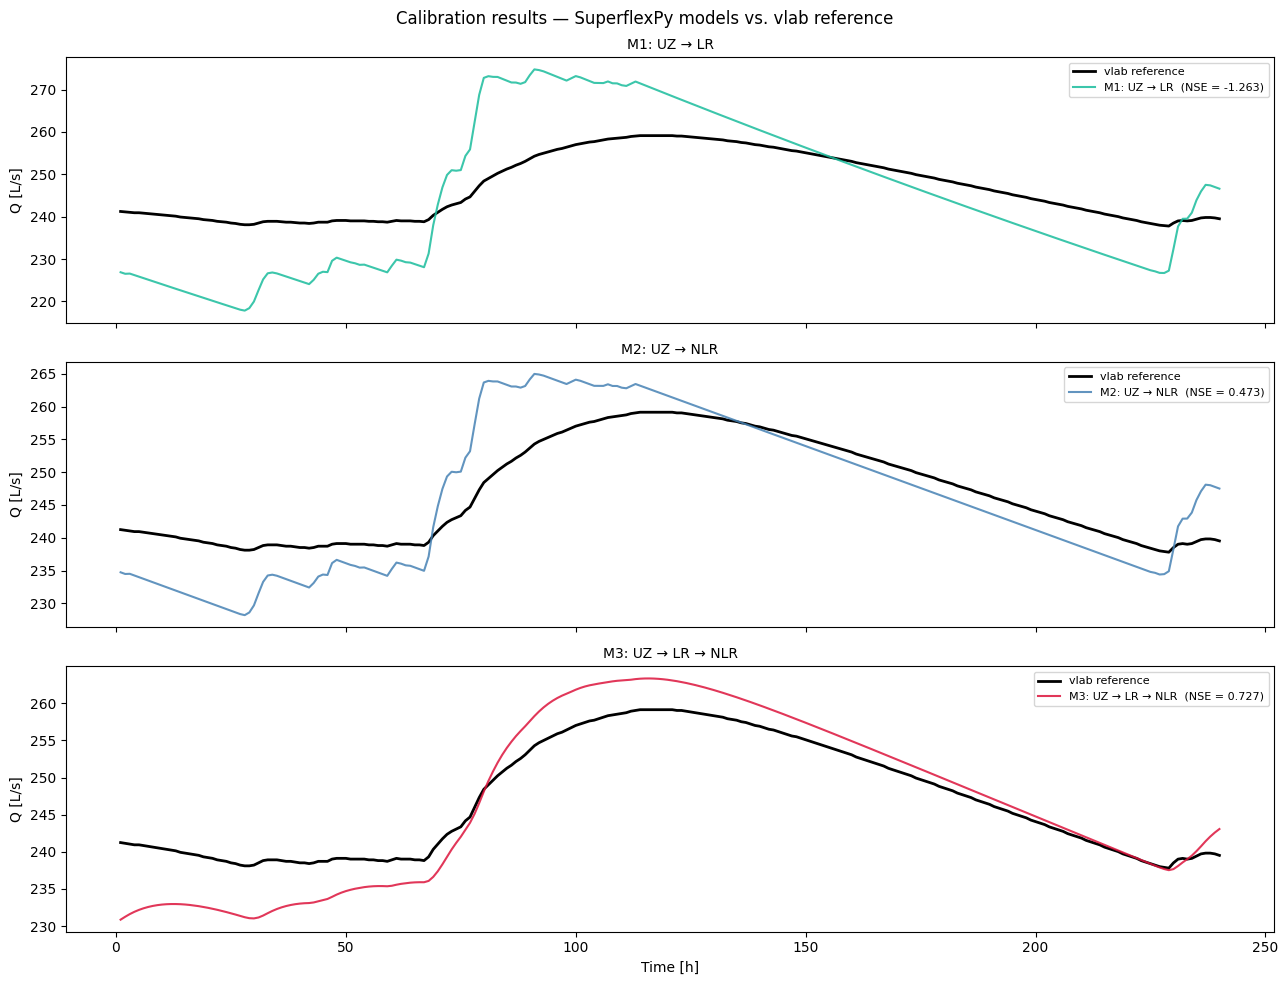

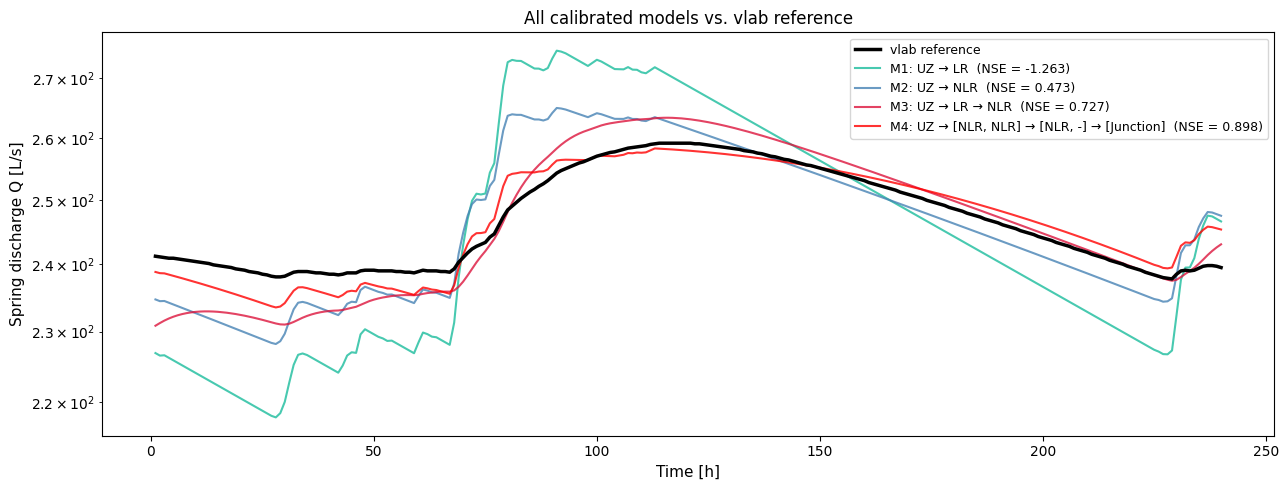

In [35]:
MODEL_COLORS = {'M1': '#1abc9c', 'M2': 'steelblue', 'M3': 'crimson', 'M4': 'red'}
MODEL_LABELS = {
    'M1': 'M1: UZ → LR',
    'M2': 'M2: UZ → NLR',
    'M3': 'M3: UZ → LR → NLR',
    'M4': 'M4: UZ → [NLR, NLR] → [NLR, -] → [Junction]',
}

# ── Figure 1: three-panel individual comparison ───────────────────────────────
fig1, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, key, Q_cal in zip(axes, ['M1', 'M2', 'M3', 'M4'], [Q_cal1, Q_cal2, Q_cal3, Q_cal4]):
    if Q_cal is None:
        continue
    nse_val = nse(Q_ref_Ls, Q_cal)
    ax.plot(t_hours, Q_ref_Ls, color='black', lw=2.0, label='vlab reference')
    ax.plot(t_hours, Q_cal, color=MODEL_COLORS[key], lw=1.5, alpha=0.85,
            label=f"{MODEL_LABELS[key]}  (NSE = {nse_val:.3f})")
    ax.set_ylabel('Q [L/s]')
    ax.set_title(MODEL_LABELS[key], fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time [h]')
plt.suptitle('Calibration results — SuperflexPy models vs. vlab reference', fontsize=12)
plt.tight_layout()
plt.show()


# ── Figure 2: combined overlay (log scale) ────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))

ax2.plot(t_hours, Q_ref_Ls, color='black', lw=2.5, zorder=10, label='vlab reference')
for key, Q_cal in zip(['M1', 'M2', 'M3', 'M4'], [Q_cal1, Q_cal2, Q_cal3, Q_cal4]):
    if Q_cal is None:
        continue
    nse_val = nse(Q_ref_Ls, Q_cal)
    ax2.plot(t_hours, Q_cal, color=MODEL_COLORS[key], lw=1.5, alpha=0.8,
             label=f"{MODEL_LABELS[key]}  (NSE = {nse_val:.3f})")

ax2.set_yscale('log')
ax2.set_xlabel('Time [h]', fontsize=11)
ax2.set_ylabel('Spring discharge Q [L/s]', fontsize=11)
ax2.set_title('All calibrated models vs. vlab reference', fontsize=12)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [37]:
def rmse(Q_obs, Q_sim):
    return float(np.sqrt(np.mean((Q_obs - Q_sim) ** 2)))


print("\n── Calibration metrics ──────────────────────────────────────────────────")
header = f"{'Model':<38}  {'NSE':>7}  {'RMSE [L/s]':>11}  {'Peak err [L/s]':>15}"
print(header)
print("-" * len(header))

for key, label, Q_cal in [
    ('M1', MODEL_LABELS['M1'], Q_cal1),
    ('M2', MODEL_LABELS['M2'], Q_cal2),
    ('M3', MODEL_LABELS['M3'], Q_cal3),
    ('M4', MODEL_LABELS['M4'], Q_cal4),
]:
    if Q_cal is None:
        continue
    nse_val  = nse(Q_ref_Ls, Q_cal)
    rmse_val = rmse(Q_ref_Ls, Q_cal)
    peak_err = abs(float(Q_ref_Ls.max()) - float(Q_cal.max()))
    print(f"{label:<38}  {nse_val:>7.4f}  {rmse_val:>11.3f}  {peak_err:>15.3f}")


── Calibration metrics ──────────────────────────────────────────────────
Model                                       NSE   RMSE [L/s]   Peak err [L/s]
-----------------------------------------------------------------------------
M1: UZ → LR                             -1.2633       11.501           15.628
M2: UZ → NLR                             0.4729        5.550            5.839
M3: UZ → LR → NLR                        0.7270        3.994            4.207
M4: UZ → [NLR, NLR] → [NLR, -] → [Junction]   0.8980        2.441            0.855
